# News Dataset EDA

This notebook performs:
- Data loading from `data/raw`
- Data preview and summary
- Missing value and duplicate checks
- Data cleaning
- Feature engineering (`text_length`, `word_count`, `uppercase_ratio`)
- Exploratory data analysis (EDA) visualizations

In [1]:
from pathlib import Path
from io import StringIO

import pandas as pd
import matplotlib.pyplot as plt

# Display settings for better readability in notebook outputs
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 150)

# Build paths relative to this notebook location
project_root = Path("..").resolve()
raw_data_dir = project_root / "data" / "raw"

print(f"Project root: {project_root}")
print(f"Raw data dir: {raw_data_dir}")

Project root: C:\Users\johnr\OneDrive\Desktop\S62-0126-powerhouse-truthmatrix\truthmatrix
Raw data dir: C:\Users\johnr\OneDrive\Desktop\S62-0126-powerhouse-truthmatrix\truthmatrix\data\raw


## 1) Load Dataset and Show Initial Overview

We load both `Fake.csv` and `True.csv`, add a `label` column, combine them into one dataset, and inspect the first rows, schema, and summary statistics.

In [2]:
fake_path = raw_data_dir / "Fake.csv"
true_path = raw_data_dir / "True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

fake_df["label"] = "fake"
true_df["label"] = "real"

df = pd.concat([fake_df, true_df], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset info:")
buffer = StringIO()
df.info(buf=buffer)
print(buffer.getvalue())

print("\nSummary statistics:")
display(df.describe(include="all").T)

Combined dataset shape: (44898, 5)

First 5 rows:


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘In The Eye’,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name Coded Into His Website (IMAGES),"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for th...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump During His Christmas Speech,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope...,News,"December 25, 2017",fake



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


Summary statistics:


,count,unique,top,freq
title,44898,38729,Factbox: Trump fills top jobs for his administration,14
text,44898,38646,,627
subject,44898,8,politicsNews,11272
date,44898,2397,"December 20, 2017",182
label,44898,2,fake,23481


### Insights: Initial Overview

- The merged dataset combines fake and real news into a single frame, making downstream comparisons easier.
- `df.info()` helps identify data types and whether any columns already contain missing values.
- `describe(include='all')` gives a broad statistical profile of both numeric and text/categorical columns.

## 2) Check Missing Values and Duplicates, Then Clean

We check null counts and duplicate rows, then clean by:
- Removing duplicate rows
- Dropping rows where core text fields are missing
- Replacing any remaining missing values in non-critical columns with safe defaults

In [3]:
print("Missing values per column (before cleaning):")
missing_before = df.isnull().sum()
display(missing_before[missing_before > 0].sort_values(ascending=False))

duplicate_count = df.duplicated().sum()
print("\nDuplicate rows (before cleaning):", duplicate_count)

# Cleaning
clean_df = df.drop_duplicates().copy()

# Ensure required text fields exist for analysis
required_cols = ["title", "text", "label"]
clean_df = clean_df.dropna(subset=required_cols)

# Fill remaining missing values in other columns
for col in clean_df.columns:
    if clean_df[col].dtype == "object":
        clean_df[col] = clean_df[col].fillna("unknown")
    else:
        clean_df[col] = clean_df[col].fillna(0)

print("\nShape before cleaning:", df.shape)
print("Shape after cleaning:", clean_df.shape)
print("Remaining missing values:", int(clean_df.isnull().sum().sum()))
print("Remaining duplicates:", int(clean_df.duplicated().sum()))

Missing values per column (before cleaning):


Series([], dtype: int64)


Duplicate rows (before cleaning): 209

Shape before cleaning: (44898, 5)
Shape after cleaning: (44689, 5)
Remaining missing values: 0
Remaining duplicates: 0


### Insights: Data Quality and Cleaning

- Duplicate removal prevents the model from overfitting repeated articles.
- Dropping rows missing core fields (`title`, `text`, `label`) keeps downstream feature engineering reliable.
- A post-cleaning check confirms whether the dataset is ready for EDA/modeling.

## 3) Feature Engineering

Create requested features from the article text:
- `text_length`: number of characters
- `word_count`: number of words
- `uppercase_ratio`: uppercase letters divided by total characters

In [4]:
clean_df["text"] = clean_df["text"].astype(str)

clean_df["text_length"] = clean_df["text"].str.len()
clean_df["word_count"] = clean_df["text"].str.split().str.len()

# Ratio of uppercase characters to total characters in each article
clean_df["uppercase_ratio"] = clean_df["text"].apply(
    lambda x: (sum(1 for ch in x if ch.isupper()) / len(x)) if len(x) > 0 else 0
)

print("Feature sample:")
display(clean_df[["text", "text_length", "word_count", "uppercase_ratio", "label"]].head())

print("\nFeature summary:")
display(clean_df[["text_length", "word_count", "uppercase_ratio"]].describe().T)

Feature sample:


,text,text_length,word_count,uppercase_ratio,label
0,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",2893,495,0.047701,fake
1,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",1898,305,0.046365,fake
2,"On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Securit...",3597,580,0.085627,fake
3,"On Christmas day, Donald Trump announced that he would be back to work the following day, but he is golfing for th...",2774,444,0.044340,fake
4,Pope Francis used his annual Christmas Day message to rebuke Donald Trump without even mentioning his name. The Pope...,2346,420,0.026854,fake



Feature summary:


,count,mean,std,min,25%,50%,75%,max
text_length,44689.0,2467.098682,2173.612347,1.0,1232.000000,2185.000000,3101.000000,51794.000000
word_count,44689.0,404.966502,351.573770,0.0,203.000000,362.000000,512.000000,8135.000000
uppercase_ratio,44689.0,0.043737,0.034890,0.0,0.030496,0.037519,0.048026,0.882353


### Insights: Engineered Features

- `text_length` and `word_count` capture article size and can expose style differences between classes.
- `uppercase_ratio` is a simple signal for writing tone/intensity.
- These features are also useful for quick baseline models and outlier detection.

## 4) EDA Visualizations

The following plots are generated:
- Histogram of `text_length`
- Boxplot of `text_length` (for outlier detection)
- Label distribution (`fake` vs `real`)
- Scatter plot: `text_length` vs label

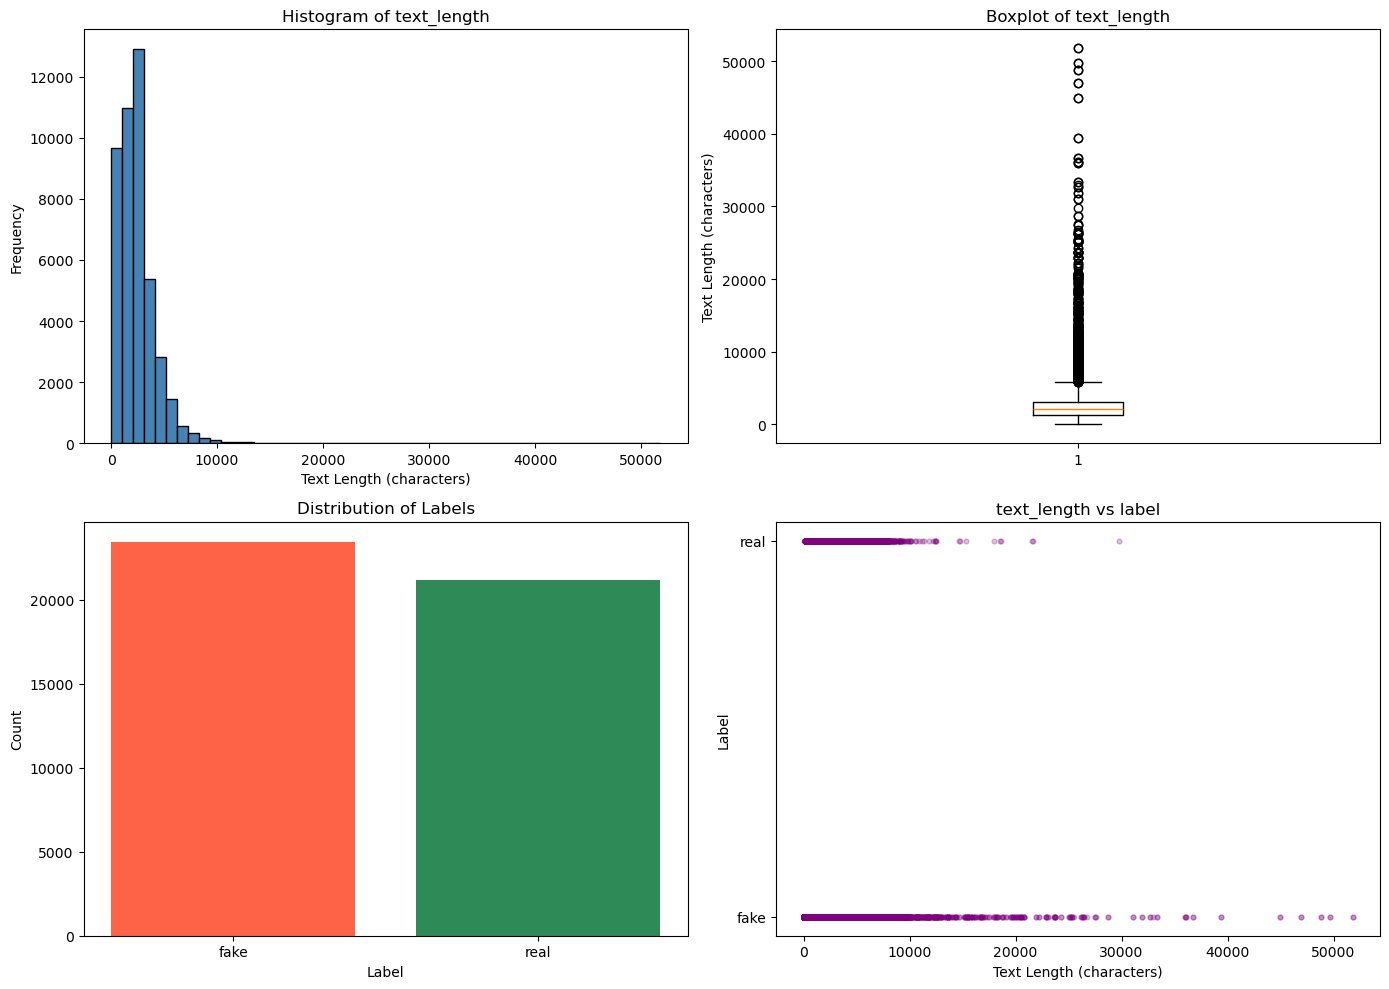

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Histogram of text_length
axes[0, 0].hist(clean_df["text_length"], bins=50, color="steelblue", edgecolor="black")
axes[0, 0].set_title("Histogram of text_length")
axes[0, 0].set_xlabel("Text Length (characters)")
axes[0, 0].set_ylabel("Frequency")

# 2) Boxplot for outlier detection
axes[0, 1].boxplot(clean_df["text_length"], vert=True)
axes[0, 1].set_title("Boxplot of text_length")
axes[0, 1].set_ylabel("Text Length (characters)")

# 3) Label distribution (fake vs real)
label_counts = clean_df["label"].value_counts()
axes[1, 0].bar(label_counts.index, label_counts.values, color=["tomato", "seagreen"])
axes[1, 0].set_title("Distribution of Labels")
axes[1, 0].set_xlabel("Label")
axes[1, 0].set_ylabel("Count")

# 4) Scatter plot: text_length vs label
label_map = {"fake": 0, "real": 1}
clean_df["label_numeric"] = clean_df["label"].map(label_map)

axes[1, 1].scatter(
    clean_df["text_length"],
    clean_df["label_numeric"],
    alpha=0.25,
    s=12,
    color="purple"
)
axes[1, 1].set_title("text_length vs label")
axes[1, 1].set_xlabel("Text Length (characters)")
axes[1, 1].set_ylabel("Label")
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_yticklabels(["fake", "real"])

plt.tight_layout()
plt.show()

### Insights: Visual EDA

- Histogram and boxplot together reveal spread and extreme-length outliers in article text.
- Label distribution shows class balance (or imbalance), which is important for model training strategy.
- Scatter of `text_length` vs label indicates whether article length alone separates fake and real classes clearly or only partially.